<a href="https://colab.research.google.com/github/DevShah2k6/PythonWork/blob/Pytorch-Projects/Pytorch_Company_Project(Custom_Dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 11.9 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import datasets,transforms
import torchvision
from torchvision.transforms import ToTensor
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchmetrics import Accuracy

In [3]:
import requests
from pathlib import Path
import zipfile

In [4]:
data_path = Path("data")
image_path = data_path/"pizza_steak_sushi"
if image_path.is_dir():
  print(f"{image_path} directory alsready exist skipping download....")
else:
  print(f"{image_path} does not exist ,creating one....")
  image_path.mkdir(parents=True,exist_ok=True)
with open(data_path/"pizza_steak_sushi.zip","wb") as f:

  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading the File")

  f.write(request.content)
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak and sushi data...")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi does not exist ,creating one....
Unzipping pizza, steak and sushi data...


In [5]:
import os
def walk_through_dir(dir_path):
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"DirPath:{len(dirpath)} DirNames:{len(dirnames)} File Names:{len(filenames)} are photos")

In [6]:
walk_through_dir(image_path)

DirPath:22 DirNames:2 File Names:0 are photos
DirPath:27 DirNames:3 File Names:0 are photos
DirPath:33 DirNames:0 File Names:19 are photos
DirPath:33 DirNames:0 File Names:25 are photos
DirPath:33 DirNames:0 File Names:31 are photos
DirPath:28 DirNames:3 File Names:0 are photos
DirPath:34 DirNames:0 File Names:75 are photos
DirPath:34 DirNames:0 File Names:78 are photos
DirPath:34 DirNames:0 File Names:72 are photos


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [8]:
!pip install Pillow

In [9]:
import random
from PIL import Image


image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

[PosixPath('data/pizza_steak_sushi/test/steak/966174.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/673127.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/690177.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1302563.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/3873283.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/3424937.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1868005.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/27415.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/354513.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/502076.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2144308.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1627703.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1882831.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2117351.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1285886.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_sus

In [10]:
random_image_path = random.choice(image_path_list)

In [11]:
img = Image.open(random_image_path)

In [12]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size=(64, 64)),

    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.TrivialAugmentWide(),

    # Turn the image into a torch.Tensor
    transforms.ToTensor()
])

In [13]:
data_transform(img)

tensor([[[0.5451, 0.5412, 0.5529,  ..., 0.5608, 0.5294, 0.5059],
         [0.5451, 0.5373, 0.5373,  ..., 0.5451, 0.5373, 0.5255],
         [0.5333, 0.5373, 0.5373,  ..., 0.5529, 0.5529, 0.5412],
         ...,
         [0.3961, 0.4000, 0.4275,  ..., 0.4000, 0.4078, 0.4235],
         [0.3961, 0.4078, 0.4275,  ..., 0.4157, 0.4000, 0.4078],
         [0.4314, 0.4392, 0.4588,  ..., 0.4118, 0.4078, 0.4275]],

        [[0.2039, 0.2039, 0.1843,  ..., 0.2118, 0.2275, 0.2471],
         [0.1961, 0.1961, 0.1922,  ..., 0.2196, 0.2275, 0.2392],
         [0.2039, 0.1961, 0.1961,  ..., 0.2078, 0.2235, 0.2353],
         ...,
         [0.2275, 0.2275, 0.2275,  ..., 0.2235, 0.2118, 0.2000],
         [0.2275, 0.2235, 0.2314,  ..., 0.2157, 0.2196, 0.2118],
         [0.2118, 0.2196, 0.2275,  ..., 0.2196, 0.2235, 0.2157]],

        [[0.0588, 0.0510, 0.0549,  ..., 0.0784, 0.0863, 0.0980],
         [0.0627, 0.0471, 0.0431,  ..., 0.0824, 0.0784, 0.0863],
         [0.0510, 0.0510, 0.0431,  ..., 0.0667, 0.0745, 0.

In [18]:
class_name = train_data.classes

NameError: name 'train_data' is not defined

In [15]:
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [26]:
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform,
    target_transform=None
)
class_name = train_data.classes
img,label = train_data[0]
label

0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

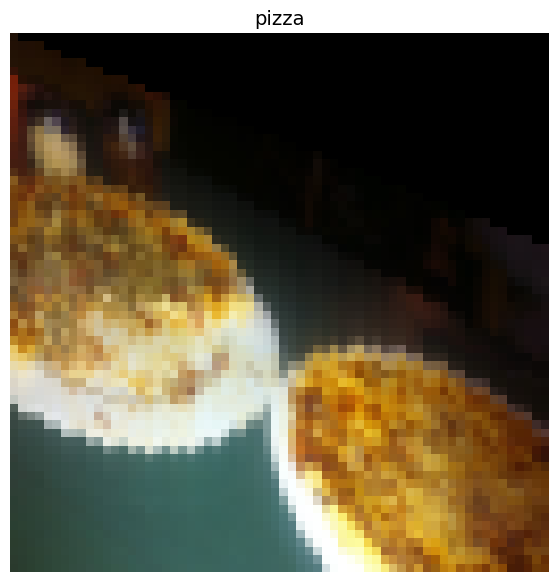

In [27]:
# img = data_transform(img) # Convert PIL Image to PyTorch Tensor
# Rearrange the order dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_name[label], fontsize=14)

In [28]:
# This cell is now redundant as class_name is defined in cell Q5Wn9vRUjcnG.

In [29]:
# The original cell Uh9n7Xg-qbdE is now redundant and can be ignored or deleted.

In [30]:
img,label = train_data[0]
label

0

Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute: torch.Size([64, 64, 3]) -> [height, width, color_channels]


Text(0.5, 1.0, 'pizza')

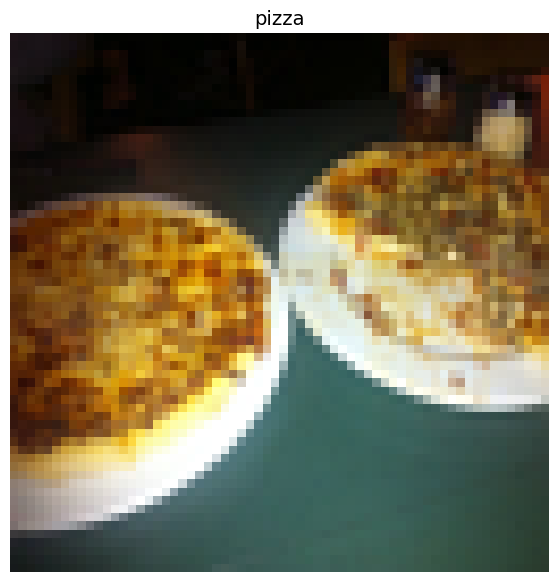

In [31]:
# Rearrange the order dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute: {img_permute.shape} -> [height, width, color_channels]")

# Plot the image
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_name[label], fontsize=14)

In [32]:
train_data

Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [33]:
test_data = datasets.ImageFolder(
    root = test_dir,
    transform = data_transform,
    target_transform=None
)

In [34]:
#Crteating DataLoader
BATCH_SIZE=32
train_data_loader = DataLoader(dataset=train_data,batch_size=BATCH_SIZE,shuffle=True)

In [35]:
test_data_loader = DataLoader(dataset=test_data,batch_size=BATCH_SIZE,shuffle=False)

In [36]:
x, y = next(iter(train_data_loader))
print(x.shape)
print(y.dtype)
print(y.min(), y.max())

torch.Size([32, 3, 64, 64])
torch.int64
tensor(0) tensor(2)


In [37]:
from torch.nn.modules.pooling import MaxPool2d
class FoodModel(nn.Module):
  def __init__(self,input_shape,hidden_units,output_shape):
    super().__init__()
    self.conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.conv_layer_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*16*16,out_features=output_shape)
    )
  def forward(self,x):
    return self.classifer(self.conv_layer_2(self.conv_layer_1(x)))

In [38]:
model = FoodModel(input_shape=3,hidden_units=32,output_shape=len(class_name))

In [39]:
#Loss Function and Optimizer
loss_fn = nn.CrossEntropyLoss()

In [40]:

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [41]:
def train_loop(model:torch.nn.Module,loss_fn,optimizer):
  model.train()
  train_loss,train_acc=0,0
  avg_train_loss,avg_train_acc=0,0
  acc = Accuracy(task="multiclass",num_classes=3)
  for x,y in train_data_loader:
    y_logits = model(x)

    loss = loss_fn(y_logits,y)
    train_loss+=loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    train_acc += acc(y_logits,y)

  avg_train_loss = train_loss/len(train_data_loader)
  avg_train_acc = train_acc/len(train_data_loader)

  return train_loss,avg_train_loss,avg_train_acc

In [42]:
def test_loop(model:torch.nn.Module,loss_fn,optimizer):
  model.eval()
  test_loss,test_acc=0,0
  avg_test_loss,avg_test_acc=0,0
  acc = Accuracy(task="multiclass",num_classes=3)
  with torch.inference_mode():
    for x,y in test_data_loader:
      y_logits_test = model(x)

      loss = loss_fn(y_logits_test,y)

      test_loss+=loss.item()

      test_acc += acc(y_logits_test,y).item()

    avg_test_loss = test_loss/len(test_data_loader)
    avg_test_acc = test_acc/len(test_data_loader)
    return test_loss,avg_test_loss,avg_test_acc

In [43]:
NUM_EPOCHS=20
training_loss=[]
testing_loss=[]
avg_training_loss=[]
avg_testing_loss=[]
avg_training_acc_list=[]
avg_testing_acc_list=[]
for epoch in tqdm(range(NUM_EPOCHS)):
    train_loss,avg_train_loss,avg_training_acc = train_loop(model=model,loss_fn=loss_fn,optimizer=optimizer)
    training_loss.append(train_loss)
    avg_training_loss.append(avg_train_loss)
    avg_training_acc_list.append(avg_training_acc)

    test_loss,avg_test_loss,avg_testing_acc = test_loop(model=model,loss_fn=loss_fn,optimizer=optimizer)
    testing_loss.append(test_loss)
    avg_testing_loss.append(avg_test_loss)
    avg_testing_acc_list.append(avg_testing_acc)
    print(f"Epoch:{epoch} | Average Train Loss:{avg_training_loss} | Average Test Loss:{avg_testing_loss} | Average Training Accuracy : {avg_training_acc} | Average Testing Accuracy : {avg_testing_acc}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch:0 | Average Train Loss:[1.1076440066099167] | Average Test Loss:[1.1430004437764485] | Average Training Accuracy : 0.26953125 | Average Testing Accuracy : 0.21875
Epoch:1 | Average Train Loss:[1.1076440066099167, 1.0899853110313416] | Average Test Loss:[1.1430004437764485, 1.1420324643452961] | Average Training Accuracy : 0.42578125 | Average Testing Accuracy : 0.19791666666666666
Epoch:2 | Average Train Loss:[1.1076440066099167, 1.0899853110313416, 1.104755848646164] | Average Test Loss:[1.1430004437764485, 1.1420324643452961, 1.1116946538289387] | Average Training Accuracy : 0.29296875 | Average Testing Accuracy : 0.23863636453946432
Epoch:3 | Average Train Loss:[1.1076440066099167, 1.0899853110313416, 1.104755848646164, 1.005601741373539] | Average Test Loss:[1.1430004437764485, 1.1420324643452961, 1.1116946538289387, 1.1063228249549866] | Average Training Accuracy : 0.51171875 | Average Testing Accuracy : 0.4526515205701192
Epoch:4 | Average Train Loss:[1.1076440066099167, 1.

In [44]:
model.eval()
with torch.inference_mode():
  for x,y in test_data_loader:
    y_pred_logits = model(x)
    y_pred_class = torch.argmax(torch.softmax(y_pred_logits,dim=1),dim=1)


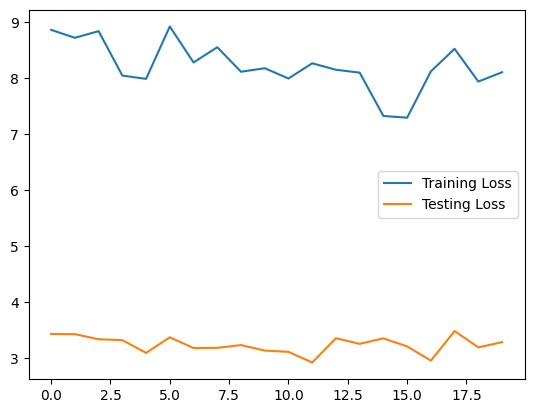

In [45]:
plt.plot(range(NUM_EPOCHS),training_loss,label="Training Loss")
plt.plot(range(NUM_EPOCHS),testing_loss,label="Testing Loss")
plt.legend()
plt.show()

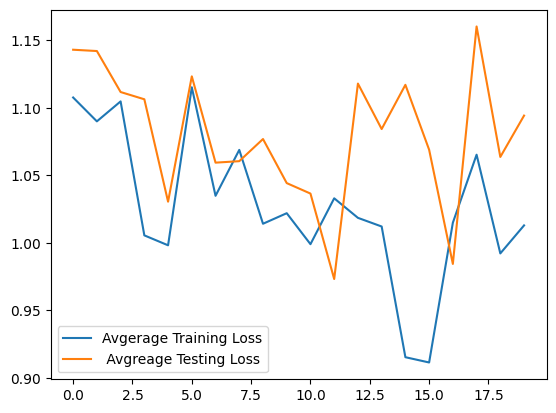

In [46]:
plt.plot(range(NUM_EPOCHS),avg_training_loss,label="Avgerage Training Loss")
plt.plot(range(NUM_EPOCHS),avg_testing_loss,label=" Avgreage Testing Loss")
plt.legend()
plt.show()

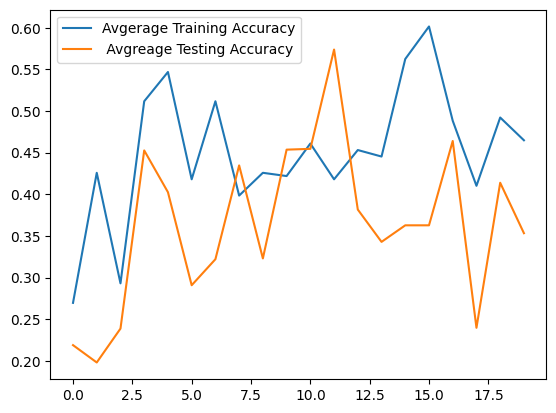

In [47]:
plt.plot(range(NUM_EPOCHS),avg_training_acc_list,label="Avgerage Training Accuracy")
plt.plot(range(NUM_EPOCHS),avg_testing_acc_list,label=" Avgreage Testing Accuracy")
plt.legend()
plt.show()

In [48]:
import requests
from pathlib import Path

custom_image_path = Path("04-pizza-dad.jpeg")

if not custom_image_path.is_file():
  with open(custom_image_path,"wb") as f:
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
    print(f"Downloading {custom_image_path} to current directory...")
    f.write(request.content)

else:
  print(f"{custom_image_path} already exists in current directory")

In [49]:
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

In [50]:
custom_image_uint8

tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

In [51]:
# Load in the custom image and convert to torch.float32
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255.
custom_image

tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..., 0.0549, 0.0510, 0.

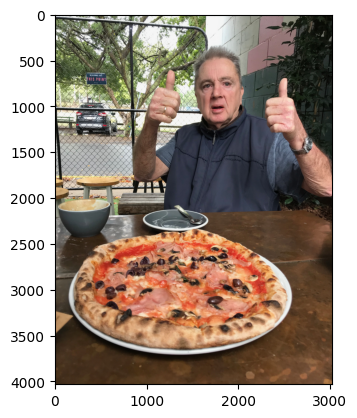

In [52]:
plt.imshow(custom_image.permute(1,2,0))

In [53]:
custom_image_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide()
])
custom_image_transformed = custom_image_transform(custom_image)


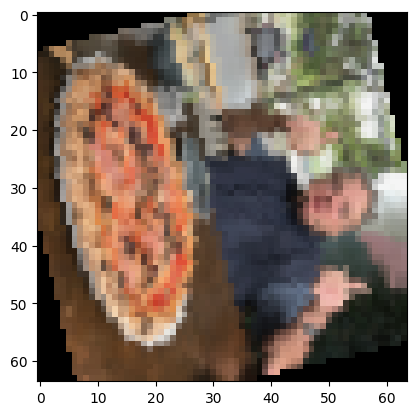

In [54]:
plt.imshow(custom_image_transformed.permute(1,2,0))

In [55]:
model.eval()
with torch.inference_mode():
  y_custom_logits = model(custom_image_transformed.unsqueeze(0))

In [56]:
y_pred_class = torch.argmax(torch.softmax(y_custom_logits,dim=1),dim=1)

Text(0.5, 1.0, 'Pred:pizza : Prob:38.61421585083008')

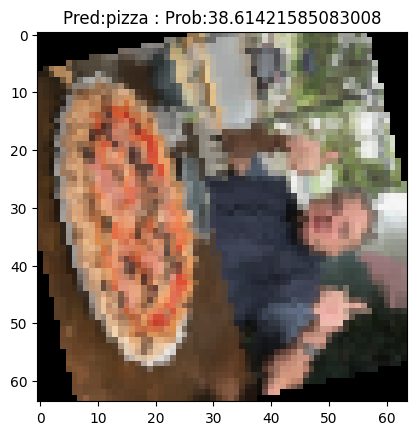

In [57]:
plt.imshow(custom_image_transformed.permute(1,2,0))
plt.title(f"Pred:{class_name[y_pred_class]} : Prob:{torch.softmax(y_custom_logits,dim=1).max()*100}")